# RQ2 Strategy Analysis

Compare the three retry context strategies in:

- `0014_minimax-cn-MiniMax-M2-5.json` -> `append`
- `0015_minimax-cn-MiniMax-M2-5.json` -> `fresh-session`
- `0016_minimax-cn-MiniMax-M2-5.json` -> `rollback`

The notebook focuses on two dimensions:

1. Score performance
2. Token efficiency

- fresh-session = 保留文件，不保留思路，失忆了，但作业还在桌上
- rollback = 文件和思路都不保留，失忆了，而且桌上的作业也被清空了
这个rq2只是看效果，其实并不能减少token，因为按理来说第一次attempt的已经被cache了，是可以直接append也不会费很多token，只是说看看压缩prompt能不能有更好的效果？

fresh-session 和 rollback 的 input_tokens 反而更高，因为它们需要重新理解或重做。

- RQ2 不是在证明“append 计费一定最低”
- 而是在测试“为了压缩 retry prompt 而丢掉上下文/状态，是否能换来更好的效果或更好的
token efficiency”
- 从结果看，没有。缓存存在时，append 保留上下文的代价并不高，而上下文连续性带来的修
复效率更有价值

RQ2实现上有问题，都没有把原始任务prompt给回去

In [1]:
from pathlib import Path
import json
import math

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [2]:
RESULT_FILES = [
    Path('/root/skill/results/rq2/0014_minimax-cn-MiniMax-M2-5.json'),
    Path('/root/skill/results/rq2/0015_minimax-cn-MiniMax-M2-5.json'),
    Path('/root/skill/results/rq2/0016_minimax-cn-MiniMax-M2-5.json'),
]


def load_result(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)


def safe_div(num, den):
    return num / den if den else math.nan


rows = []
attempt_rows = []

for path in RESULT_FILES:
    data = load_result(path)
    task = data['tasks'][0]
    strategy = task['retry_policies']['context_policy']
    usage = task['usage']
    score = float(task['grading_summary']['mean'])
    total_tokens = int(usage['total_tokens'])
    input_tokens = int(usage['input_tokens'])
    output_tokens = int(usage['output_tokens'])
    cache_read = int(usage['cache_read_tokens'])
    cache_write = int(usage['cache_write_tokens'])

    rows.append({
        'run_id': data['run_id'],
        'file': path.name,
        'strategy': strategy,
        'score': score,
        'passed': bool(task['completion']['passed']),
        'attempt_count': int(task['attempt_count']),
        'llm_rounds': int(task['llm_rounds']),
        'execution_time_s': float(task['execution_time']),
        'input_tokens': input_tokens,
        'output_tokens': output_tokens,
        'cache_read_tokens': cache_read,
        'cache_write_tokens': cache_write,
        'total_tokens': total_tokens,
        'prompt_tokens_by_attempt': task['prompt_tokens_by_attempt'],
        'completion_tokens_by_attempt': task['completion_tokens_by_attempt'],
        'score_per_1k_total_tokens': safe_div(score, total_tokens / 1000),
        'score_per_1k_input_tokens': safe_div(score, input_tokens / 1000),
        'tokens_per_score_total': safe_div(total_tokens, score),
        'tokens_per_score_input': safe_div(input_tokens, score),
        'cache_read_share_of_total': safe_div(cache_read, total_tokens),
        'non_cache_share_of_total': safe_div(input_tokens + output_tokens, total_tokens),
    })

    for attempt in task['attempts']:
        a_usage = attempt['execution']['usage']
        attempt_rows.append({
            'run_id': data['run_id'],
            'strategy': strategy,
            'attempt': int(attempt['attempt']),
            'session_reset': bool(attempt['session_reset']),
            'workspace_restored': bool(attempt['workspace_restored']),
            'input_tokens': int(a_usage['input_tokens']),
            'output_tokens': int(a_usage['output_tokens']),
            'cache_read_tokens': int(a_usage['cache_read_tokens']),
            'cache_write_tokens': int(a_usage['cache_write_tokens']),
            'total_tokens': int(a_usage['total_tokens']),
            'request_count': int(a_usage['request_count']),
            'transcript_length': int(attempt['transcript_length']),
            'unresolved_criteria_count': int(attempt['unresolved_criteria_count']),
        })

summary_df = pd.DataFrame(rows).sort_values(['score', 'score_per_1k_total_tokens'], ascending=[False, False])
attempt_df = pd.DataFrame(attempt_rows).sort_values(['strategy', 'attempt'])

summary_df[['run_id', 'strategy', 'score', 'llm_rounds', 'attempt_count', 'input_tokens', 'cache_read_tokens', 'total_tokens', 'score_per_1k_total_tokens', 'score_per_1k_input_tokens', 'tokens_per_score_total', 'tokens_per_score_input']]

,run_id,strategy,score,llm_rounds,attempt_count,input_tokens,cache_read_tokens,total_tokens,score_per_1k_total_tokens,score_per_1k_input_tokens,tokens_per_score_total,tokens_per_score_input
0,0014,append,0.9167,8,2,7884,72891,94252,0.0097,0.1163,"102,820.3636","8,600.7273"
2,0016,rollback,0.9167,15,2,25742,156225,186244,0.0049,0.0356,"203,175.2727","28,082.1818"
1,0015,fresh-session,0.8942,11,2,13598,114573,130967,0.0068,0.0658,"146,468.2199","15,207.4557"


## Score Comparison

In [3]:
score_cols = ['strategy', 'score', 'passed', 'attempt_count', 'llm_rounds', 'execution_time_s']
summary_df[score_cols].sort_values('score', ascending=False)

,strategy,score,passed,attempt_count,llm_rounds,execution_time_s
0,append,0.9167,False,2,8,28.1710
2,rollback,0.9167,False,2,15,154.4417
1,fresh-session,0.8942,False,2,11,114.4130


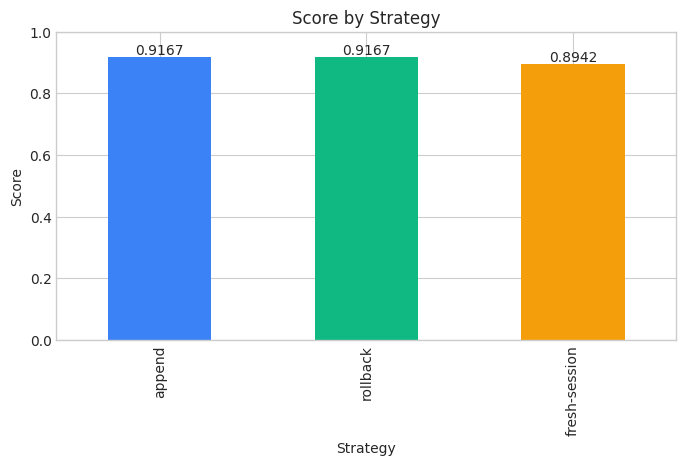

In [4]:
ax = summary_df.sort_values('score', ascending=False).plot(
    x='strategy', y='score', kind='bar', legend=False, figsize=(8, 4), color=['#3b82f6', '#10b981', '#f59e0b']
)
ax.set_title('Score by Strategy')
ax.set_xlabel('Strategy')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.show()

## Token Efficiency Comparison

Two views are useful here:

- `score_per_1k_total_tokens`: score divided by all tokens, including cache read/write
- `score_per_1k_input_tokens`: score divided by non-cache input tokens only

The first matches overall resource cost more closely inside these result files. The second isolates how much fresh prompt input each strategy consumed.

In [5]:
eff_cols = [
    'strategy',
    'score',
    'input_tokens',
    'cache_read_tokens',
    'total_tokens',
    'score_per_1k_total_tokens',
    'score_per_1k_input_tokens',
    'tokens_per_score_total',
    'tokens_per_score_input',
    'cache_read_share_of_total',
]
summary_df[eff_cols].sort_values('score_per_1k_total_tokens', ascending=False)

,strategy,score,input_tokens,cache_read_tokens,total_tokens,score_per_1k_total_tokens,score_per_1k_input_tokens,tokens_per_score_total,tokens_per_score_input,cache_read_share_of_total
0,append,0.9167,7884,72891,94252,0.0097,0.1163,"102,820.3636","8,600.7273",0.7734
1,fresh-session,0.8942,13598,114573,130967,0.0068,0.0658,"146,468.2199","15,207.4557",0.8748
2,rollback,0.9167,25742,156225,186244,0.0049,0.0356,"203,175.2727","28,082.1818",0.8388


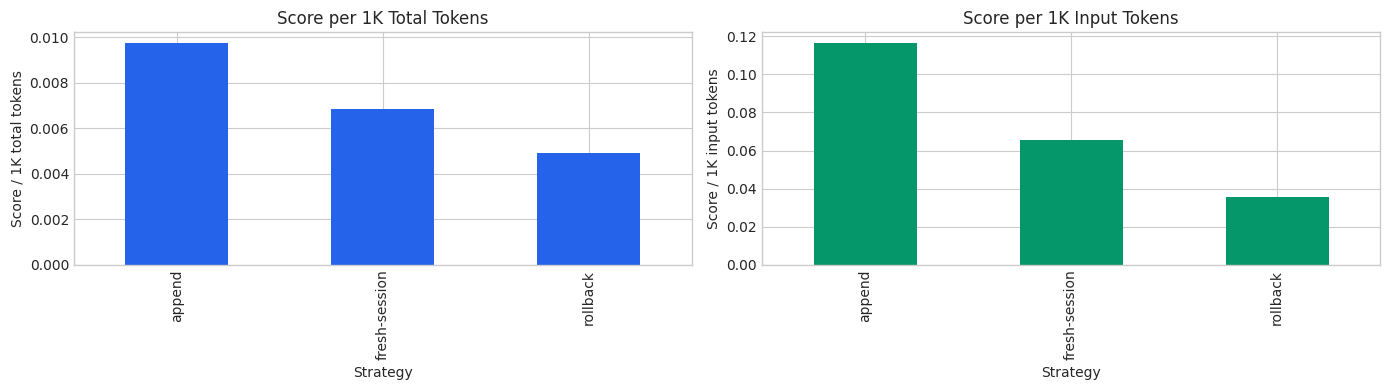

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

summary_df.sort_values('score_per_1k_total_tokens', ascending=False).plot(
    x='strategy', y='score_per_1k_total_tokens', kind='bar', legend=False, ax=axes[0], color='#2563eb'
)
axes[0].set_title('Score per 1K Total Tokens')
axes[0].set_xlabel('Strategy')
axes[0].set_ylabel('Score / 1K total tokens')

summary_df.sort_values('score_per_1k_input_tokens', ascending=False).plot(
    x='strategy', y='score_per_1k_input_tokens', kind='bar', legend=False, ax=axes[1], color='#059669'
)
axes[1].set_title('Score per 1K Input Tokens')
axes[1].set_xlabel('Strategy')
axes[1].set_ylabel('Score / 1K input tokens')

plt.tight_layout()
plt.show()

## Attempt-Level Breakdown

In [7]:
attempt_df

,run_id,strategy,attempt,session_reset,workspace_restored,input_tokens,output_tokens,cache_read_tokens,cache_write_tokens,total_tokens,request_count,transcript_length,unresolved_criteria_count
0,0014,append,1,False,False,1772,830,31239,10443,44284,4,12,4
1,0014,append,2,False,False,6112,959,41652,1245,49968,4,20,1
2,0015,fresh-session,1,False,False,2096,1035,41682,0,44813,4,12,3
3,0015,fresh-session,2,True,False,11502,1348,72891,413,86154,7,19,3
4,0016,rollback,1,False,False,2073,965,41682,0,44720,4,12,1
5,0016,rollback,2,True,True,23669,2950,114543,362,141524,11,26,1


In [8]:
pivot_attempt = attempt_df.pivot(index='strategy', columns='attempt', values='input_tokens').rename(columns=lambda c: f'attempt_{c}_input')
pivot_attempt

attempt,attempt_1_input,attempt_2_input
strategy,,
append,1772,6112
fresh-session,2096,11502
rollback,2073,23669


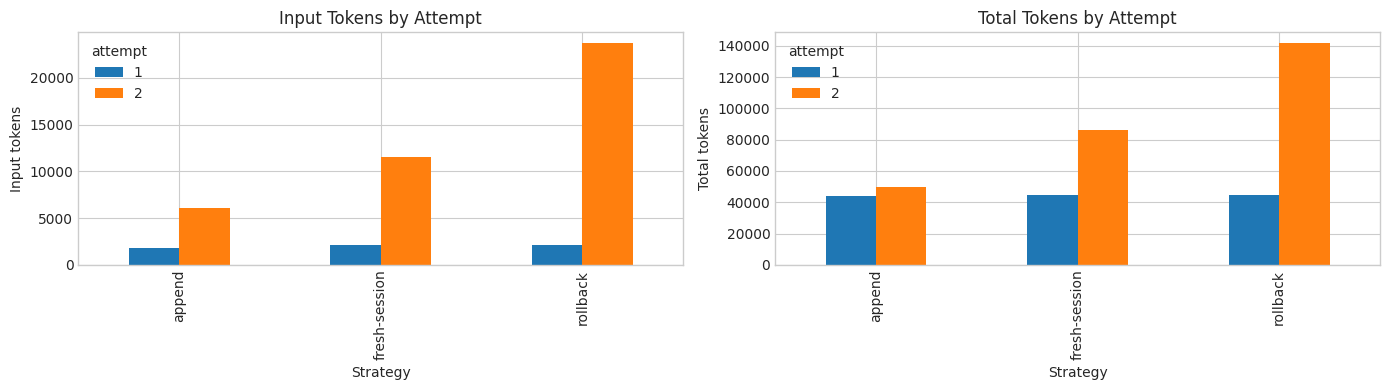

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

attempt_df.pivot(index='strategy', columns='attempt', values='input_tokens').plot(kind='bar', ax=axes[0])
axes[0].set_title('Input Tokens by Attempt')
axes[0].set_xlabel('Strategy')
axes[0].set_ylabel('Input tokens')

attempt_df.pivot(index='strategy', columns='attempt', values='total_tokens').plot(kind='bar', ax=axes[1])
axes[1].set_title('Total Tokens by Attempt')
axes[1].set_xlabel('Strategy')
axes[1].set_ylabel('Total tokens')

plt.tight_layout()
plt.show()

## Compact Ranking Tables

In [10]:
score_ranking = summary_df[['strategy', 'score', 'llm_rounds', 'total_tokens']].sort_values(['score', 'total_tokens'], ascending=[False, True]).reset_index(drop=True)
score_ranking.index = score_ranking.index + 1
score_ranking

,strategy,score,llm_rounds,total_tokens
1,append,0.9167,8,94252
2,rollback,0.9167,15,186244
3,fresh-session,0.8942,11,130967


In [11]:
eff_ranking = summary_df[['strategy', 'score_per_1k_total_tokens', 'score_per_1k_input_tokens', 'tokens_per_score_total', 'tokens_per_score_input']].sort_values('score_per_1k_total_tokens', ascending=False).reset_index(drop=True)
eff_ranking.index = eff_ranking.index + 1
eff_ranking

,strategy,score_per_1k_total_tokens,score_per_1k_input_tokens,tokens_per_score_total,tokens_per_score_input
1,append,0.0097,0.1163,"102,820.3636","8,600.7273"
2,fresh-session,0.0068,0.0658,"146,468.2199","15,207.4557"
3,rollback,0.0049,0.0356,"203,175.2727","28,082.1818"


## Notebook Conclusion

Run the next cell to generate a short text summary directly from the measured values.

In [12]:
best_score = summary_df.sort_values(['score', 'total_tokens'], ascending=[False, True]).iloc[0]
best_eff_total = summary_df.sort_values('score_per_1k_total_tokens', ascending=False).iloc[0]
best_eff_input = summary_df.sort_values('score_per_1k_input_tokens', ascending=False).iloc[0]
lowest_total_tokens = summary_df.sort_values('total_tokens').iloc[0]

print('Best score strategy:', best_score['strategy'], f"(score={best_score['score']:.4f}, total_tokens={int(best_score['total_tokens'])})")
print('Best total-token efficiency:', best_eff_total['strategy'], f"(score_per_1k_total_tokens={best_eff_total['score_per_1k_total_tokens']:.4f})")
print('Best input-token efficiency:', best_eff_input['strategy'], f"(score_per_1k_input_tokens={best_eff_input['score_per_1k_input_tokens']:.4f})")
print('Lowest total token usage:', lowest_total_tokens['strategy'], f"(total_tokens={int(lowest_total_tokens['total_tokens'])})")

print('\nInterpretation:')
for _, row in summary_df.sort_values('strategy').iterrows():
    print(
        f"- {row['strategy']}: score={row['score']:.4f}, rounds={int(row['llm_rounds'])}, "
        f"input={int(row['input_tokens'])}, cache_read={int(row['cache_read_tokens'])}, total={int(row['total_tokens'])}, "
        f"score/1k total={row['score_per_1k_total_tokens']:.4f}, score/1k input={row['score_per_1k_input_tokens']:.4f}"
    )

Best score strategy: append (score=0.9167, total_tokens=94252)
Best total-token efficiency: append (score_per_1k_total_tokens=0.0097)
Best input-token efficiency: append (score_per_1k_input_tokens=0.1163)
Lowest total token usage: append (total_tokens=94252)

Interpretation:
- append: score=0.9167, rounds=8, input=7884, cache_read=72891, total=94252, score/1k total=0.0097, score/1k input=0.1163
- fresh-session: score=0.8942, rounds=11, input=13598, cache_read=114573, total=130967, score/1k total=0.0068, score/1k input=0.0658
- rollback: score=0.9167, rounds=15, input=25742, cache_read=156225, total=186244, score/1k total=0.0049, score/1k input=0.0356
